In [42]:
!pip install -q rasterio

In [43]:
import numpy as np
import random
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import tifffile as tiff
import tifffile
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import pickle


# Dataset paths
DATASET_DIR = Path("/kaggle/input/cloud-masking-dataset/content/train")
IMGS_DIR = DATASET_DIR / "data"
MASKS_DIR = DATASET_DIR / "masks"

# Dice score function
def dice_score(pred, target, epsilon=1e-6):
    pred = pred.flatten()
    target = target.flatten()
    intersection = (pred * target).sum()
    return (2. * intersection) / (pred.sum() + target.sum() + epsilon)

def read_tiff(file_path):
    try:
        img = tifffile.imread(file_path)
        # If image is 3D, ensure it has 4 channels (R,G,B,NIR)
        if len(img.shape) == 3:
            if img.shape[0] == 4:  # Channels first
                img = np.transpose(img, (1, 2, 0))
            elif img.shape[0] != 4 and img.shape[2] == 4:
                pass  # Already in the right format (H,W,C)
            else:
                raise ValueError(f"Unexpected image shape: {img.shape}")
        
        # Normalize each channel separately to [0, 1]
        img = img.astype(np.float32)
        for i in range(img.shape[2]):
            channel = img[:, :, i]
            min_val = np.min(channel)
            max_val = np.max(channel)
            if max_val > min_val:
                img[:, :, i] = (channel - min_val) / (max_val - min_val)
        
        return img
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        raise e

# Load training data from multiple images
def load_training_data(num_images=1000, pixels_per_image=1000):
    X, y = [], []
    image_files = list(IMGS_DIR.glob("*.tif"))
    random.shuffle(image_files)
    image_files = image_files[:num_images]

    for img_path in tqdm(image_files, desc="Loading data"):
        mask_path = MASKS_DIR / img_path.name

        img = tiff.imread(img_path)
        mask = tiff.imread(mask_path)

        H, W, C = img.shape
        img_reshaped = img.reshape(-1, C)
        mask_reshaped = mask.reshape(-1)

        indices = np.random.choice(H * W, size=pixels_per_image, replace=False)
        X.append(img_reshaped[indices])
        y.append(mask_reshaped[indices])

    X = np.concatenate(X, axis=0)
    y = np.concatenate(y, axis=0)
    return X, y

# Train Random Forest classifier
def train_random_forest():
    # Load training data (sampled pixels)
    X_train, y_train = load_training_data(num_images=4000, pixels_per_image=2000)
    
    # Load full validation images
    image_files = list(IMGS_DIR.glob("*.tif"))
    random.shuffle(image_files)
    val_files = image_files[4000:4400]  # Take 400 images for validation
    
    X_val_full = []
    y_val_full = []
    
    for img_path in tqdm(val_files, desc="Loading validation data"):
        mask_path = MASKS_DIR / img_path.name
        
        img = tiff.imread(img_path)
        mask = tiff.imread(mask_path)
        
        H, W, C = img.shape
        X_val_full.append(img.reshape(-1, C))
        y_val_full.append(mask.reshape(-1))
    
    model = RandomForestClassifier(n_estimators=20, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    # Evaluate on full validation images
    total_dice = 0
    for X_val, y_val in zip(X_val_full, y_val_full):
        y_pred = model.predict(X_val)
        
        # Convert to tensors for dice score calculation
        pred_tensor = torch.tensor(y_pred.reshape(-1), dtype=torch.float32)
        mask_tensor = torch.tensor(y_val.reshape(-1), dtype=torch.float32)
        
        dice = dice_score(pred_tensor, mask_tensor)
        total_dice += dice
    
    avg_dice = total_dice / len(val_files)
    print(f"Average Validation Dice Score (full masks): {avg_dice:.4f}")

    with open('random_forest_cloud_mask.pkl', 'wb') as f:
        pickle.dump(model, f)
    print("Model saved as 'random_forest_cloud_mask.pkl'")
    
    return model

# ------------------------------
# Train model and test on an image
# ------------------------------
model = train_random_forest()

Loading validation data: 100%|██████████| 400/400 [00:04<00:00, 92.21it/s] 


Average Validation Dice Score (full masks): 0.7707
Model saved as 'random_forest_cloud_mask.pkl'


In [44]:
# Predict and visualize results for a specific image by name
def predict_and_display_by_name(name, model):
    image_path = IMGS_DIR / f"{name}.tif"
    mask_path = MASKS_DIR / f"{name}.tif"

    image = tiff.imread(image_path)
    H, W, C = image.shape

    flat_pixels = image.reshape(-1, C)
    preds = model.predict(flat_pixels)
    pred_mask = preds.reshape(H, W)

    # If ground truth exists, compute Dice score
    if mask_path.exists():
        gt_mask = tiff.imread(mask_path)
        pred_tensor = torch.tensor(pred_mask, dtype=torch.float32)
        mask_tensor = torch.tensor(gt_mask, dtype=torch.float32)
        dice = dice_score(mask_tensor, pred_tensor)
        print(f"Dice Score: {dice:.4f}")

    image = read_tiff(image_path)

    # Visualization
    fig, ax = plt.subplots(1, 4 if mask_path.exists() else 3, figsize=(15, 5))
    ax[0].imshow(image[:, :, :3])
    ax[0].set_title("Input Image (RGB)")
    ax[1].imshow(image[:, :, 3], cmap='inferno')
    ax[1].set_title("Infrared Band")

    if mask_path.exists():
        ax[2].imshow(gt_mask, cmap='gray')
        ax[2].set_title("Ground Truth Mask")
        ax[3].imshow(pred_mask, cmap='gray')
        ax[3].set_title("Predicted Mask")
    else:
        ax[2].imshow(pred_mask, cmap='gray')
        ax[2].set_title("Predicted Mask")

    for a in ax:
        a.axis('off')
    plt.tight_layout()
    plt.show()


Dice Score: 0.8791


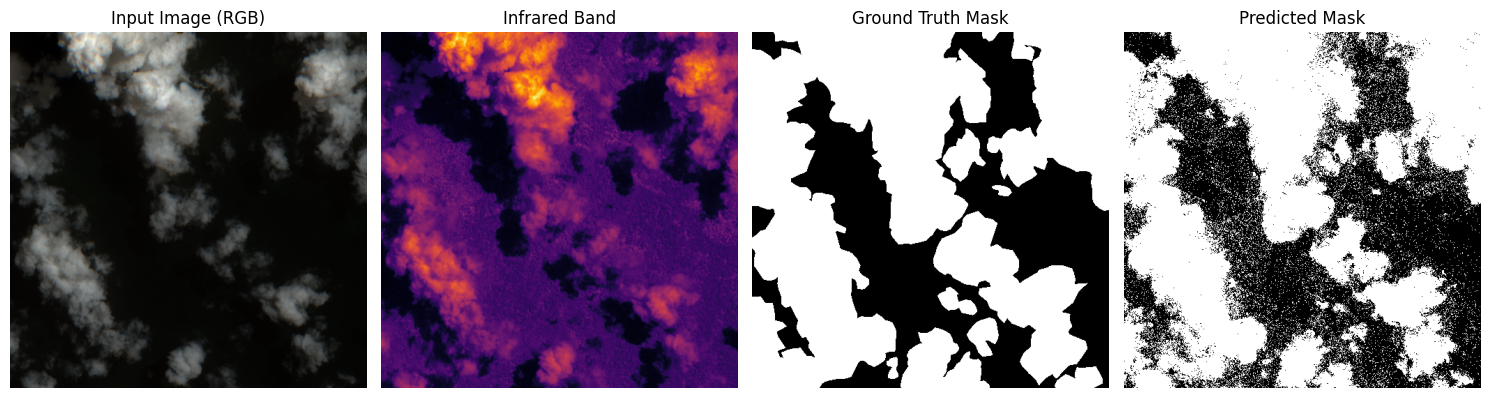

In [45]:
predict_and_display_by_name("100425", model)

In [46]:
def model_stats(model, path='random_forest_cloud_mask.pkl'):
    import os

    size_mb = os.path.getsize(path) / (1024 * 1024)
    n_trees = len(model.estimators_)
    total_nodes = sum(e.tree_.node_count for e in model.estimators_)
    avg_depth = sum(e.tree_.max_depth for e in model.estimators_) / n_trees
    approx_ops = n_trees * avg_depth

    print("🔍 Model Statistics:")
    print(f"📦 File Size: {size_mb:.2f} MB")
    print(f"🌲 Number of Trees: {n_trees}")
    print(f"🔗 Total Nodes (All Trees): {total_nodes}")
    print(f"📏 Average Tree Depth: {avg_depth:.2f}")
    print(f"⚙️  Approximate Operations per Prediction: {approx_ops:.0f}")

model_stats(model)

🔍 Model Statistics:
📦 File Size: 2315.74 MB
🌲 Number of Trees: 20
🔗 Total Nodes (All Trees): 33725258
📏 Average Tree Depth: 59.15
⚙️  Approximate Operations per Prediction: 1183
